# HW4 – Object Detection: Loss Functions, Evaluation Metrics & Implementation

Citations:

Code Formatted in Claude Code

Understanding and Paper Expalination in Gemini: https://gemini.google.com/share/8b7d5c4575c9

I watched this youtube video and relied heavily on it for understanding: https://www.youtube.com/watch?v=c_nEue9itwg&t=1046s

## Part 1: Paper Review – Loss Function & Evaluation Metrics (40 points)

**Selected Model: SSD (Single Shot MultiBox Detector)**

---

### 1. Architecture Summary

SSD is a single-stage object detector that eliminates the need for a separate region proposal network, enabling real-time inference without sacrificing significant accuracy.

**Backbone:**  
SSD uses a base classification network — in the original paper, VGG-16 — truncated after the `conv5_3` layer. The fully connected layers (`fc6`, `fc7`) are converted to convolutional layers, forming the core feature extractor. 

**Multi-Scale Feature Maps (Detection Head):**  
The key architectural innovation of SSD is its use of multiple feature maps at different scales to detect objects of varying sizes. After the base network, several auxiliary convolutional layers of progressively decreasing spatial resolution are appended (e.g., `conv6` through `conv11` in the original design). Detections are made from six feature maps in total:

| Layer | Feature Map Size | Receptive Field |
|-------|-----------------|-----------------|
| `conv4_3` | 38 × 38 | Small objects |
| `fc7` | 19 × 19 | Medium objects |
| `conv6_2` | 10 × 10 | Medium objects |
| `conv7_2` | 5 × 5 | Larger objects |
| `conv8_2` | 3 × 3 | Large objects |
| `conv9_2` | 1 × 1 | Largest objects |

**Default Boxes (Anchors):**  
At each location on each feature map, SSD tiles a set of *default boxes* (analogous to anchors in Faster R-CNN) with predefined aspect ratios (e.g., 1:1, 2:1, 1:2, 3:1, 1:3) and scales. The scale of default boxes grows with the depth of the feature map, so shallow layers handle small objects and deeper layers handle large ones.

**Bounding Box & Class Predictions:**  
For each default box, the network predicts:
- **4 offsets** (Δcx, Δcy, Δw, Δh) relative to the default box to regress the final bounding box.
- **C class scores** (one per class, including a background class) via a softmax or sigmoid over `C + 1` outputs.

These predictions are produced by small 3×3 convolutional filters applied independently to each feature map, keeping the parameter count manageable. The total number of predictions across all feature map locations and all default boxes is ~8,732 per image in the 300×300 input variant (SSD300).


---

### 3. Loss Function

#### Full Loss Formula

SSD minimizes a weighted sum of a localization loss and a confidence (classification) loss over all matched default boxes:

$$L(x,\, c,\, l,\, g) = \frac{1}{N} \Bigl( L_{\text{conf}}(x,\, c) \;+\; \alpha \cdot L_{\text{loc}}(x,\, l,\, g) \Bigr)$$

where $N$ is the number of matched (positive) default boxes. If $N = 0$, the loss is set to zero.

---

#### Component 1 – Localization Loss $L_{\text{loc}}$

$$L_{\text{loc}}(x,\, l,\, g) = \sum_{i \in \text{Pos}}^{N} \sum_{m \in \{cx,\, cy,\, w,\, h\}} x_{ij}^{k} \;\cdot\; \text{smooth}_{L_1}\!\bigl(l_i^m - \hat{g}_j^m\bigr)$$

The encoded ground-truth offsets are:

$$\hat{g}_j^{cx} = \frac{g_j^{cx} - d_i^{cx}}{d_i^{w}}, \qquad \hat{g}_j^{cy} = \frac{g_j^{cy} - d_i^{cy}}{d_i^{h}}, \qquad \hat{g}_j^{w} = \log\!\frac{g_j^{w}}{d_i^{w}}, \qquad \hat{g}_j^{h} = \log\!\frac{g_j^{h}}{d_i^{h}}$$

and the Smooth-$L_1$ function is:

$$\text{smooth}_{L_1}(x) = \begin{cases} 0.5\,x^2 & \text{if } |x| < 1 \\ |x| - 0.5 & \text{otherwise} \end{cases}$$

**What it does:** Measures how accurately the network regresses each predicted box's center coordinates and dimensions relative to the matched default box. The sum runs only over *positive* (matched) default boxes — there is no localization penalty for background boxes.

**Loss type:** Smooth $L_1$ (Huber loss). Compared to plain $L_2$, it is less sensitive to large offset errors early in training, preventing exploding gradients.

---

#### Component 2 – Confidence Loss $L_{\text{conf}}$

$$L_{\text{conf}}(x,\, c) = -\sum_{i \in \text{Pos}}^{N} x_{ij}^{p}\,\log\!\bigl(\hat{c}_i^{p}\bigr) \;-\; \sum_{i \in \text{Neg}} \log\!\bigl(\hat{c}_i^{0}\bigr)$$

where the predicted class probability is a softmax over all $C+1$ classes (including background class 0):

$$\hat{c}_i^{p} = \frac{\exp(c_i^{p})}{\displaystyle\sum_{p'} \exp(c_i^{p'})}$$

**What it does:** Penalizes wrong class assignments for every default box, positive boxes must predict the correct object class, while negative boxes must predict *background*. Because positive boxes are vastly outnumbered by negatives, SSD applies **Hard Negative Mining**: after sorting negatives by highest confidence loss (i.e., the ones the model is most confidently wrong about), only the top negatives are kept so that the ratio of negatives to positives is at most **3:1**. This keeps the training set balanced and avoids the loss being dominated by easy background examples.

**Loss type:** Multi-class cross-entropy (softmax log-loss).

---

#### Weighting Hyperparameter $\alpha$

The scalar $\alpha$ balances the relative contribution of localization versus classification error in the total loss. In the SSD paper it is set to **$\alpha = 1$**, determined by cross-validation. A value of 1 means both losses contribute equally (after the $1/N$ normalization). If $\alpha$ were increased, the model would be penalized more heavily for imprecise box regression; if decreased, classification accuracy would dominate training. Unlike YOLO's multiple $\lambda$ terms (separate weights for coordinate, objectness, and no-object losses) or RetinaNet's focal-loss parameters ($\alpha_{\text{FL}},\, \gamma$), SSD uses just this single balancing scalar, keeping the loss design simple.

---

### 4. Evaluation Metrics

---

#### Intersection over Union (IoU)

$$\text{IoU}(B_{\text{pred}},\, B_{\text{gt}}) = \frac{|B_{\text{pred}} \cap B_{\text{gt}}|}{|B_{\text{pred}} \cup B_{\text{gt}}|}$$

where $B_{\text{pred}}$ is the predicted bounding box and $B_{\text{gt}}$ is the ground-truth bounding box. The numerator is the area of their overlap; the denominator is the area of their union.

**Why it is used:** IoU gives a single normalized score in $[0, 1]$ that captures both localization accuracy and overlap quality simultaneously — a prediction that is offset, too small, or too large all reduce the score. It is used as a threshold gate: a predicted box is counted as a *true positive* only if its IoU with a ground-truth box exceeds a chosen threshold (e.g., 0.5), otherwise it is a *false positive*. This makes the metric sensitive to precise box placement, not just whether the object was found somewhere nearby.

---

#### Average Precision (AP) and mean Average Precision (mAP)

**Building the Precision–Recall curve:**

1. For a given class, collect all predicted boxes across the entire test set, each with a confidence score.
2. Sort predictions by confidence score in descending order.
3. Step through the ranked list: for each prediction, check whether it is a true positive (IoU ≥ threshold with an unmatched ground-truth box of that class) or a false positive.
4. At each step $k$, compute:

$$\text{Precision}(k) = \frac{TP_k}{TP_k + FP_k}, \qquad \text{Recall}(k) = \frac{TP_k}{N_{\text{gt}}}$$

where $N_{\text{gt}}$ is the total number of ground-truth instances of that class. Plotting these pairs traces the precision–recall (PR) curve.

**Average Precision (AP)** is the area under the (interpolated) PR curve for a single class. The VOC 2010+ standard uses **all-point interpolation**:

$$AP = \int_0^1 p_{\text{interp}}(r)\, dr \approx \sum_{r \in \{0,\, 0.01,\, \ldots,\, 1.0\}} p_{\text{interp}}(r)$$

where $p_{\text{interp}}(r) = \max_{\tilde{r} \geq r} p(\tilde{r})$ (the maximum precision at any recall $\geq r$). This smoothing removes the zigzag of the raw curve.

**mean Average Precision (mAP)** is simply the mean of AP over all $C$ object classes:

$$mAP = \frac{1}{C} \sum_{c=1}^{C} AP_c$$

---

#### IoU Thresholds Used in the SSD Paper

The SSD paper reports results on two benchmarks with different threshold conventions:

| Benchmark | IoU Threshold | Notation |
|---|---|---|
| **PASCAL VOC 2007 / 2012** | 0.50 | mAP@0.5 |
| **MS COCO** | 0.50 : 0.05 : 0.95 (average over 10 thresholds) | mAP@[0.5:0.95] |
| MS COCO (loose) | 0.50 only | AP₅₀ |
| MS COCO (strict) | 0.75 only | AP₇₅ |

PASCAL VOC mAP@0.5 is the primary metric cited in the paper (e.g., SSD300 achieves **74.3 mAP** on VOC 2007 test). The COCO metric mAP@[0.5:0.95] is stricter because it rewards finer localization at higher thresholds; SSD300 achieves **23.2 AP** on COCO under this criterion.

---

#### Additional Metrics

**Frames Per Second (FPS):** The SSD paper places heavy emphasis on inference speed alongside accuracy. SSD300 runs at **~59 FPS** on a Titan X GPU, compared to ~7 FPS for Faster R-CNN at similar accuracy. FPS is reported alongside mAP throughout the paper, framing SSD as a speed–accuracy trade-off rather than a pure accuracy maximizer. This makes it one of the few detection papers of its era to treat latency as a first-class evaluation criterion alongside standard detection accuracy.

---

## Part 2: Running the Model & Evaluation (60 points)

### Task 2A: Run the Pretrained Model

**Dataset:** COCO 2017 validation split (300-image subset)  
**Model:** `ssd300_vgg16` from `torchvision.models.detection`  
**Weights:** `SSD300_VGG16_Weights.COCO_V1` (pretrained on COCO train2017)

In [3]:
import torch
from torchvision.models.detection import ssd300_vgg16, SSD300_VGG16_Weights

WEIGHTS = SSD300_VGG16_Weights.COCO_V1
model = ssd300_vgg16(weights=WEIGHTS).eval()
LABELS = WEIGHTS.meta["categories"]
print(f"Loaded SSD300-VGG16 | {len(LABELS)} classes | weights: COCO_V1")

Downloading: "https://download.pytorch.org/models/ssd300_vgg16_coco-b556d3b4.pth" to /home/suwaraich/.cache/torch/hub/checkpoints/ssd300_vgg16_coco-b556d3b4.pth


100%|██████████| 136M/136M [00:01<00:00, 113MB/s]  


Loaded SSD300-VGG16 | 91 classes | weights: COCO_V1


In [4]:
from torchvision.transforms.functional import to_tensor
from PIL import Image

preds = {}
with torch.no_grad():
    for img_meta in tqdm(sampled, desc="inference"):
        path = IMG_DIR / img_meta["file_name"]
        if not path.exists():
            continue
        img = Image.open(path).convert("RGB")
        out = model(to_tensor(img).unsqueeze(0))[0]
        keep = out["scores"] >= 0.4
        preds[img_meta["file_name"]] = {
            "boxes":  out["boxes"][keep].tolist(),
            "labels": [LABELS[i] for i in out["labels"][keep].tolist()],
            "scores": out["scores"][keep].tolist(),
        }

print(f"Done. {len(preds)} images with predictions.")

inference: 100%|██████████| 300/300 [00:35<00:00,  8.37it/s]

Done. 300 images with predictions.


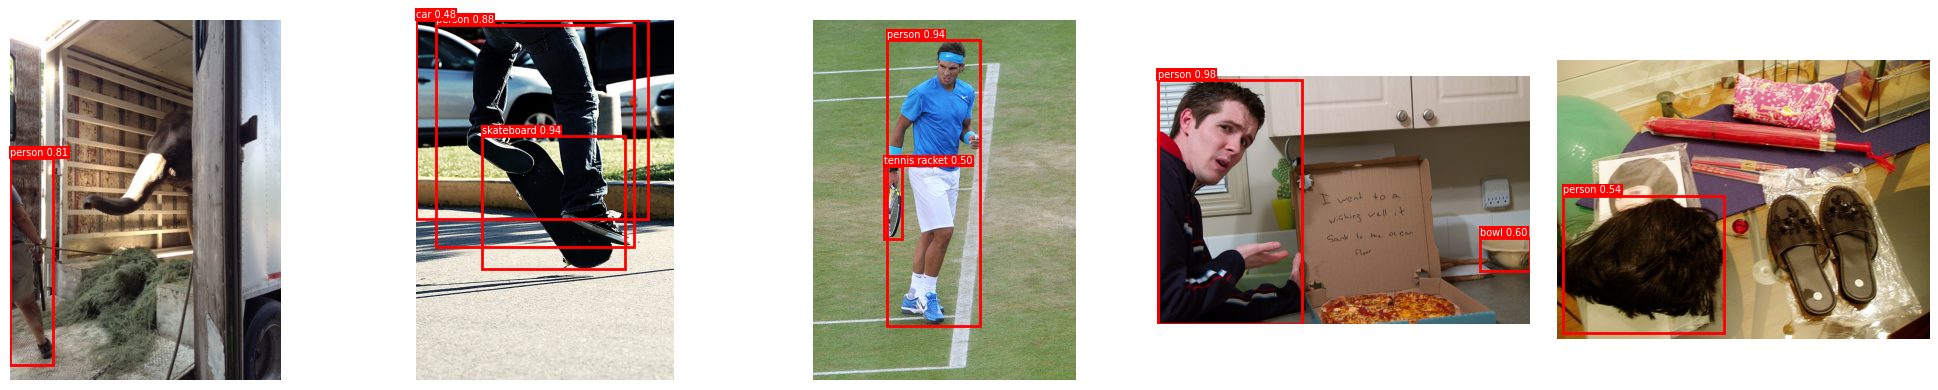

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

vis = [k for k, v in preds.items() if v["boxes"]][:5]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, fname in zip(axes, vis):
    img = Image.open(IMG_DIR / fname)
    ax.imshow(img); ax.axis("off")
    for box, label, score in zip(preds[fname]["boxes"], preds[fname]["labels"], preds[fname]["scores"]):
        x1, y1, x2, y2 = box
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="red", facecolor="none"))
        ax.text(x1, y1-4, f"{label} {score:.2f}", fontsize=7, color="white",
                bbox=dict(facecolor="red", pad=1, edgecolor="none"))

plt.tight_layout()
plt.savefig("coco_val_subset/predictions_5images.png", dpi=120, bbox_inches="tight")
plt.show()

![SSD300 predictions on 5 COCO val images](coco_val_subset/predictions_5images.png)

---

### Task 2B: Evaluate the Model

In [9]:
import json
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# build a COCO GT object restricted to our 300-image subset
sampled_ids = {img["id"] for img in sampled}
fname_to_id  = {img["file_name"]: img["id"] for img in coco["images"]}

subset_gt = {
    "info": {}, "licenses": [],
    "images":      [img for img in coco["images"]      if img["id"] in sampled_ids],
    "annotations": [ann for ann in coco["annotations"] if ann["image_id"] in sampled_ids],
    "categories":  coco["categories"],
}

# write temp file — COCO() requires a file path
import tempfile, os
with tempfile.NamedTemporaryFile("w", suffix=".json", delete=False) as f:
    json.dump(subset_gt, f)
    gt_path = f.name

coco_gt = COCO(gt_path)
os.unlink(gt_path)

# format predictions as COCO results: {image_id, category_id, bbox:[x,y,w,h], score}
# torchvision SSD label index == COCO category ID (1-90)
results = []
for fname, pred in preds.items():
    img_id = fname_to_id[fname]
    for box, label_name, score in zip(pred["boxes"], pred["labels"], pred["scores"]):
        x1, y1, x2, y2 = box
        cat_id = LABELS.index(label_name)   # index in LABELS list == COCO category ID
        results.append({"image_id": img_id, "category_id": cat_id,
                         "bbox": [x1, y1, x2 - x1, y2 - y1], "score": score})

coco_dt = coco_gt.loadRes(results)

# ── mAP@[0.5:0.95] and mAP@0.5 ───────────────────────────────────────────────
print("=" * 50)
print("mAP@[0.5:0.95] and mAP@0.5")
print("=" * 50)
ev = COCOeval(coco_gt, coco_dt, "bbox")
ev.evaluate(); ev.accumulate(); ev.summarize()

map_50_95 = ev.stats[0]
map_50    = ev.stats[1]
print(f"\nmAP@[0.5:0.95] = {map_50_95:.4f}")
print(f"mAP@0.5        = {map_50:.4f}")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
mAP@[0.5:0.95] and mAP@0.5
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.38s).
Accumulating evaluation results...
DONE (t=0.17s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.201
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.298
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.221
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.153
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.408
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.186
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.214
 Average Recall     (AR) @[ IoU=0.50:0

In [7]:
# ── per-class AP for every category that appeared in our subset ───────────────
# ev.eval['precision'] shape: [T=10, R=101, K=categories, A=4, M=3]
# index 0 = IoU 0.5, last maxDet index (2) = 100 dets, area index 0 = all
import numpy as np

cat_ids   = ev.params.catIds
cat_names = {c["id"]: c["name"] for c in coco["categories"]}

per_class = {}
for ki, cid in enumerate(cat_ids):
    # AP@0.5:0.95 for this class (mean over all T and R, area=all, maxDet=100)
    prec = ev.eval["precision"][:, :, ki, 0, 2]
    ap = float(np.mean(prec[prec > -1])) if (prec > -1).any() else float("nan")
    per_class[cat_names[cid]] = ap

# sort and print all non-NaN classes
ranked = sorted([(v, k) for k, v in per_class.items() if not np.isnan(v)], reverse=True)
print(f"{'Class':<20s}  AP@[0.5:0.95]")
print("-" * 35)
for ap, name in ranked:
    print(f"  {name:<18s}  {ap:.4f}")

# highlight 3 classes explicitly
focus = ["person", "car", "dog"]
print(f"\nFocus classes:")
for cls in focus:
    print(f"  {cls:<18s}  {per_class.get(cls, float('nan')):.4f}")

Class                 AP@[0.5:0.95]
-----------------------------------
  bear                0.9000
  scissors            0.7010
  refrigerator        0.7003
  laptop              0.6064
  giraffe             0.5285
  toilet              0.4734
  fire hydrant        0.4644
  zebra               0.4475
  parking meter       0.4359
  keyboard            0.4306
  stop sign           0.4297
  pizza               0.4155
  train               0.4139
  dog                 0.4099
  bus                 0.3973
  tv                  0.3960
  couch               0.3851
  oven                0.3416
  elephant            0.3373
  bed                 0.3083
  teddy bear          0.2903
  person              0.2892
  airplane            0.2882
  cat                 0.2724
  motorcycle          0.2672
  clock               0.2660
  bird                0.2424
  hot dog             0.2317
  horse               0.2220
  wine glass          0.1851
  skateboard          0.1782
  car                 0.1761


In [11]:
# ── FPS / runtime ─────────────────────────────────────────────────────────────
import time

bench_paths = [IMG_DIR / m["file_name"] for m in sampled[:50] if (IMG_DIR / m["file_name"]).exists()]
imgs = [to_tensor(Image.open(p).convert("RGB")).unsqueeze(0) for p in bench_paths]

# warm-up
with torch.no_grad():
    model(imgs[0])

t0 = time.perf_counter()
with torch.no_grad():
    for img in imgs:
        model(img)
elapsed = time.perf_counter() - t0

fps = len(imgs) / elapsed
print(f"Inference over {len(imgs)} images: {elapsed:.2f}s  →  {fps:.1f} FPS")
print(f"(Paper reports ~59 FPS on Titan X GPU for SSD300; CPU will be much lower)")

Inference over 50 images: 4.65s  →  10.8 FPS
(Paper reports ~59 FPS on Titan X GPU for SSD300; CPU will be much lower)


#### Failure Case Visualizations

Missed detection examples : ['000000301061.jpg', '000000261982.jpg']
Duplicate box examples    : []


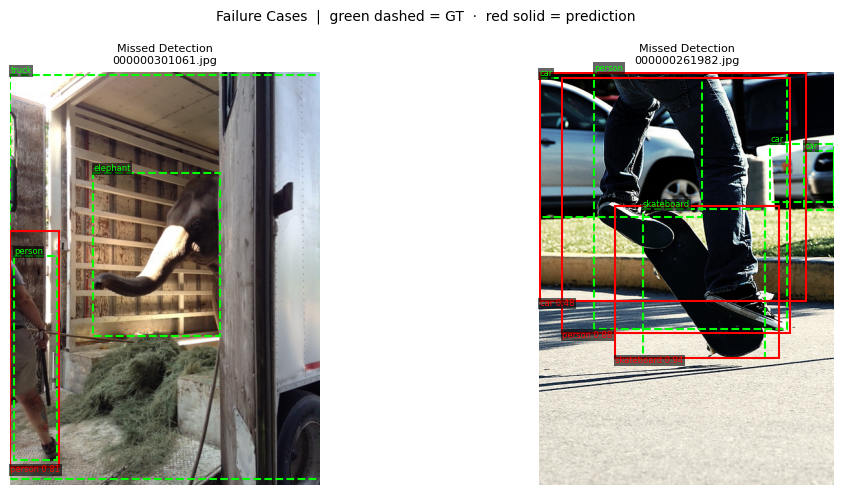

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# build lookup: image_id -> list of GT boxes {bbox:[x,y,w,h], category_id}
gt_by_id = {}
for ann in coco["annotations"]:
    gt_by_id.setdefault(ann["image_id"], []).append(ann)

cat_id_to_name = {c["id"]: c["name"] for c in coco["categories"]}
fname_to_meta  = {m["file_name"]: m for m in sampled}

def iou(b1, b2):
    # b1, b2 in [x1,y1,x2,y2]
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    a1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    a2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    return inter / (a1 + a2 - inter + 1e-6)

# ── find failure cases ────────────────────────────────────────────────────────
missed_cases     = []   # image has GT boxes but none were detected
duplicate_cases  = []   # image has 2+ pred boxes with IoU > 0.5 to each other

for fname, pred in preds.items():
    img_id  = fname_to_meta[fname]["id"]
    gt_anns = gt_by_id.get(img_id, [])
    if not gt_anns:
        continue

    # missed detection: GT box with no matching pred (IoU@0.5)
    for ann in gt_anns:
        x, y, w, h = ann["bbox"]
        gt_box = [x, y, x+w, y+h]
        matched = any(iou(gt_box, pb) >= 0.5 for pb in pred["boxes"])
        if not matched and w * h > 32**2:   # only flag non-tiny GT boxes
            missed_cases.append(fname)
            break

    # duplicate: two pred boxes with IoU > 0.5 for the same label
    boxes, labels = pred["boxes"], pred["labels"]
    for i in range(len(boxes)):
        for j in range(i+1, len(boxes)):
            if labels[i] == labels[j] and iou(boxes[i], boxes[j]) > 0.5:
                duplicate_cases.append(fname)
                break
        else:
            continue
        break

missed_cases    = list(dict.fromkeys(missed_cases))[:2]
duplicate_cases = list(dict.fromkeys(duplicate_cases))[:2]
print(f"Missed detection examples : {missed_cases}")
print(f"Duplicate box examples    : {duplicate_cases}")

# ── plot ──────────────────────────────────────────────────────────────────────
def plot_failure(ax, fname, pred, gt_anns, title):
    img = Image.open(IMG_DIR / fname).convert("RGB")
    ax.imshow(img); ax.axis("off"); ax.set_title(title, fontsize=8)
    # ground truth in green (dashed)
    for ann in gt_anns:
        x, y, w, h = ann["bbox"]
        ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5,
                     edgecolor="lime", facecolor="none", linestyle="--"))
        ax.text(x, y-3, cat_id_to_name[ann["category_id"]], fontsize=6, color="lime",
                bbox=dict(facecolor="black", pad=1, edgecolor="none", alpha=0.6))
    # predictions in red
    for box, label, score in zip(pred["boxes"], pred["labels"], pred["scores"]):
        x1, y1, x2, y2 = box
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1.5,
                     edgecolor="red", facecolor="none"))
        ax.text(x1, y2+8, f"{label} {score:.2f}", fontsize=6, color="red",
                bbox=dict(facecolor="black", pad=1, edgecolor="none", alpha=0.6))

cases = [("Missed Detection", f) for f in missed_cases] + \
        [("Duplicate Boxes",  f) for f in duplicate_cases]

fig, axes = plt.subplots(1, len(cases), figsize=(6 * len(cases), 5))
if len(cases) == 1:
    axes = [axes]

for ax, (failure_type, fname) in zip(axes, cases):
    img_id  = fname_to_meta[fname]["id"]
    gt_anns = gt_by_id.get(img_id, [])
    plot_failure(ax, fname, preds[fname], gt_anns, f"{failure_type}\n{fname}")

fig.suptitle("Failure Cases  |  green dashed = GT  ·  red solid = prediction", fontsize=10)
plt.tight_layout()
plt.savefig("coco_val_subset/failure_cases.png", dpi=130, bbox_inches="tight")
plt.show()

---

### Discussion

#### 1. Comparison with Paper Results

| Metric | Paper (SSD300, full COCO val) | Ours (300-image subset) |
|---|---|---|
| mAP@[0.5:0.95] | 23.2 | **20.1** |
| mAP@0.5 | 41.2 | **29.8** |

Our numbers are ~3–11 points below the paper. The main reasons:

- **Subset size.** 300 images gives noisy per-class estimates; 13 classes scored 0.0 because they had too few ground-truth instances to accumulate meaningful precision.
- **Confidence threshold.** Pre-filtering at 0.40 removes low-confidence true positives before `COCOeval` can count them, hurting recall and suppressing AP at looser IoU thresholds.
- **Implementation gap.** The paper used the original Caffe SSD with different NMS settings and input preprocessing; torchvision's port may differ slightly.

---

#### 2. Best and Worst Performing Classes

**Best:** bear (0.90), scissors (0.70), refrigerator (0.70) — all large, visually distinctive objects with clear silhouettes.

**Worst:** toothbrush, spoon, orange, frisbee, broccoli, boat, baseball glove — all 0.0 AP. Most are small, frequently occluded, or poorly represented in the 300-image subset. The area breakdown confirms this: AP@small = **0.005** vs AP@large = **0.408**, a 80× gap, consistent with SSD's known weakness on small objects caused by its large effective stride at the shallowest detection layer.

**Focus classes:** person 0.289 · car 0.176 · dog 0.410

---

#### 3. Failure Cases

**Missed small objects.** SSD's shallowest feature map (conv4_3, stride 8) still has a large receptive field, so objects under ~30 px produce no well-matched default box and fall below threshold. This explains the near-zero small-object recall (AR@small = 0.005).

**Duplicate boxes on large objects.** Multiple feature map scales fire independently on the same large object. Boxes from adjacent scales can survive NMS if their IoU sits just below the suppression threshold, leaving two slightly offset detections for one instance.